<a href="https://colab.research.google.com/github/FernandoMRestelli/datascience-portfolio/blob/master/California_housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
df = data.frame

In [2]:
## Buscamos predecir el valor medio por bloque/manzana (MedHouseVal) a partir de las otras variables.

In [3]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [4]:
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

1.EDA

Detectar ooutliers.
Ver la distribución de los datos
Identificar datos faltantes.
ver relaciones entre variables. (Correlaciones)
Relaciones con el target.
Detectar desbalance de clases.
Entender variables categoricas y su distribución.
Detectar multicolinealidad - Propblemas en modelo lineales.



In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


array([[<Axes: title={'center': 'MedInc'}>,
        <Axes: title={'center': 'HouseAge'}>,
        <Axes: title={'center': 'AveRooms'}>],
       [<Axes: title={'center': 'AveBedrms'}>,
        <Axes: title={'center': 'Population'}>,
        <Axes: title={'center': 'AveOccup'}>],
       [<Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>,
        <Axes: title={'center': 'MedHouseVal'}>]], dtype=object)

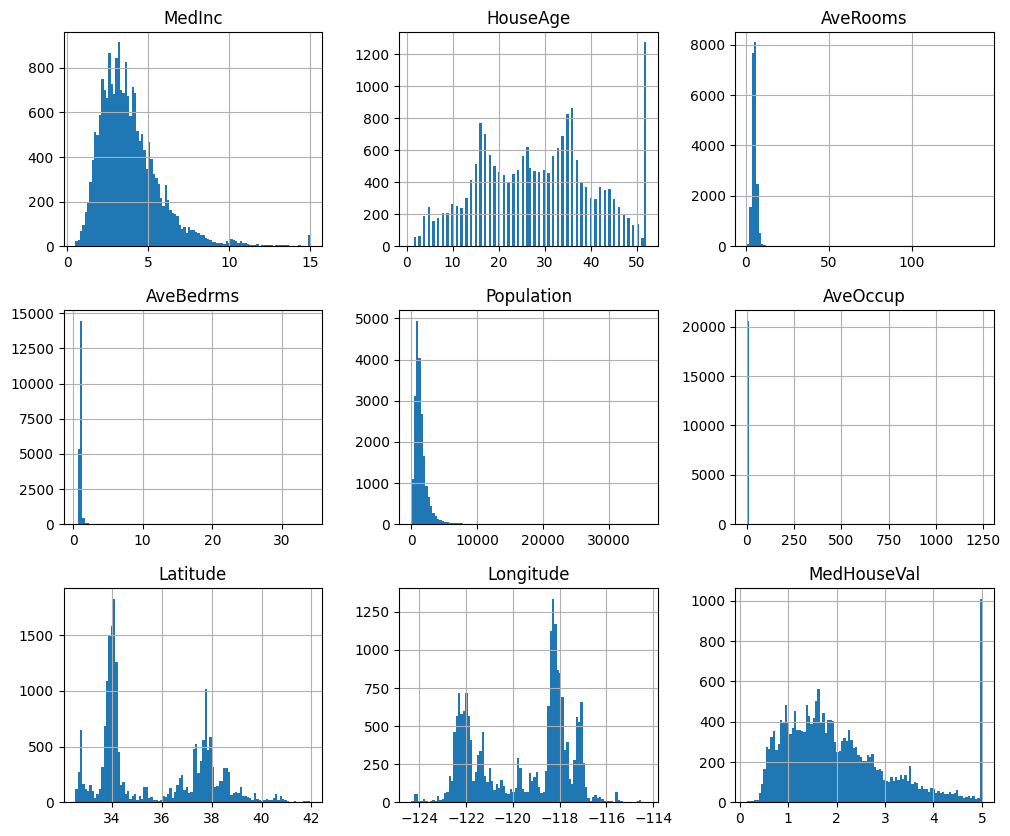

In [6]:
df.hist(figsize=(12,10), bins=100)

<Axes: >

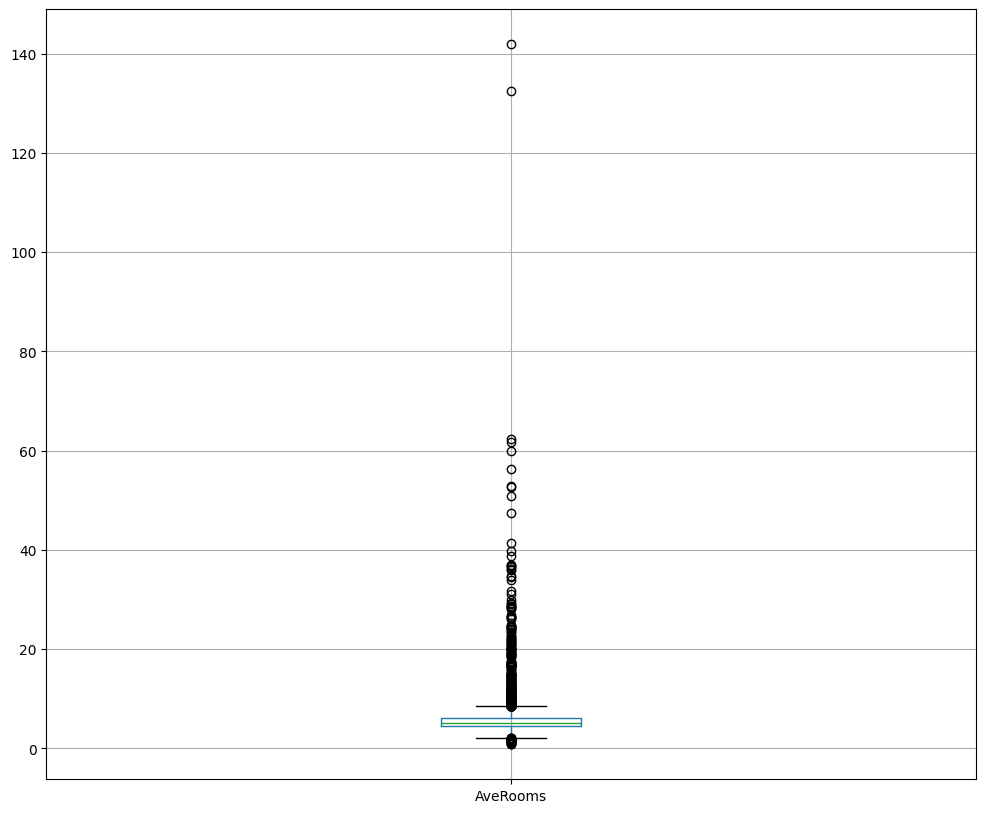

In [7]:
df.boxplot(figsize=(12,10), column=['AveRooms'])


MedInc: USD anuales (x 10.000) todas estan alrededor de 3.8. Excepto algunos que estan en 15 (Imputar?).
HouseAge: Edad de la casa. La mayoria de las casas tienen entre 1 y 50 años. Hay algunos outliers que tienen mas de 50 años (Imputar?). Afecta a modelos? A cuales?
AveRooms: Numero de habitaciones promedio por block. La mayoria de las block tienen entre 0 y 2 habitaciones.
Etc:
                                                                                                                            

                                                                                              

In [8]:
df.isnull().sum().sort_values(ascending=False)

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


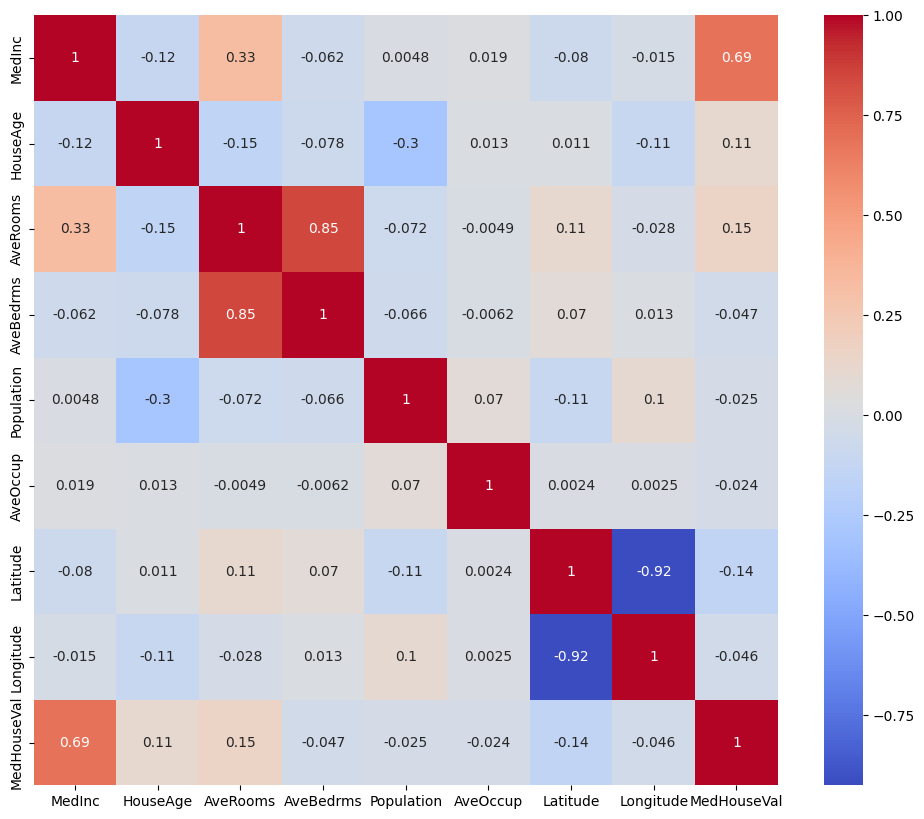

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()


Correlaciones entre varialbres = colinealidad(Afecta mucho explicabilidad y da algo de inestablidad a la cap del modelo); AvgBedrms con AveRooms; Solo eliminiaría elgunas de estas 2 para evitar la colinealidad. Está arriba de 80. Dsp hay casios extraños, como Layt y Long, que no hay que eliminarn.
variables claves: MedInc, HouseAge, AveRooms, lat.


In [10]:
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [12]:
## Pipeline 1: Eliminado outliers y variables con alta correlación para modelos como Regresión Lineal y KNN.

In [13]:
import numpy as np

X_train_clean = X_train.copy()
X_train_clean.drop(columns=['AveBedrms'], inplace=True)
X_train_clean['AveRooms'] = np.clip(X_train_clean['AveRooms'], 0, 50)


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

pipe_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipe_knn = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', KNeighborsRegressor())
])

pipe_svr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', SVR())
])


pipe_RF = Pipeline([
    ('model', RandomForestRegressor())
])

pipe_XGB = Pipeline([
    ('model', XGBRegressor())
])




In [15]:
### Comparación inicial de modelos. Para ver cual promete más.

from sklearn.model_selection import cross_validate
import pandas as pd


models = {
    'LinearRegression': pipe_lr,
    'KNN': pipe_knn,
    'SVR': pipe_svr,
    'RandomForest': pipe_RF,
    'XGBoost': pipe_XGB
}

scoring = {
    'r2': 'r2',
    'mse': 'neg_mean_squared_error'
}

results = []

for name, pipe in models.items():
    res = cross_validate(pipe, X_train, y_train, cv=5, scoring=scoring)

    results.append({
        'model': name,
        'mean_r2': res['test_r2'].mean(),
        'std_r2': res['test_r2'].std(),
        'mean_mse': -res['test_mse'].mean(),  # ⚠️ invertir signo
        'std_mse': res['test_mse'].std()
    })

results_df = pd.DataFrame(results).sort_values(by='mean_r2', ascending=False)

results_df



,model,mean_r2,std_r2,mean_mse,std_mse
4,XGBoost,0.827105,0.009554,0.230458,0.009813
3,RandomForest,0.802249,0.010439,0.263605,0.010595
2,SVR,0.735152,0.016667,0.353044,0.018810
1,KNN,0.678555,0.021385,0.428367,0.022288
0,LinearRegression,0.601061,0.014074,0.531871,0.010016


In [16]:
### Optimización de modelos. Para ver si podemos mejorar el rendimiento.
from sklearn.model_selection import GridSearchCV

## Tuneo de Hyperparametros para SVR y KNN

param_grid_svr = {
    'model__C': [0.1, 1, 10],
    'model__gamma': ['scale', 0.01, 0.1],
    'model__epsilon': [0.05, 0.1, 0.2]
}

grid_svr = GridSearchCV(
    pipe_svr,
    param_grid_svr,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)


param_grid_knn = {
    'model__n_neighbors': [3,5,7,10,15],
    'model__weights': ['uniform', 'distance'],
    'model__p': [1, 2]  # Manhattan vs Euclidean
}

grid_knn = GridSearchCV(
    pipe_knn,
    param_grid_knn,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    return_train_score=True

)


grid_svr.fit(X_train, y_train)
grid_knn.fit(X_train, y_train)

grid_svr.best_params_
grid_svr.best_score_
grid_knn.best_params_
grid_knn.best_score_

best_svr = grid_svr.best_estimator_
best_knn = grid_knn.best_estimator_


Fitting 5 folds for each of 27 candidates, totalling 135 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [17]:
from sklearn.metrics import r2_score, mean_squared_error


models = {
    'LinearRegression': pipe_lr,
    'KNN': best_knn,
    'SVR': best_svr
}


results_test = []

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    results_test.append({
        'model': name,
        'r2': r2_score(y_test, y_pred),
        'mse': mean_squared_error(y_test, y_pred)
    })

pd.DataFrame(results_test).sort_values(by='r2', ascending=False)

,model,r2,mse
2,SVR,0.758491,0.318849
1,KNN,0.737840,0.346113
0,LinearRegression,0.605251,0.521162


In [18]:
# Pipeline 2: dataset entero para Modelos de Ensamble como Random Forest y XGBoost. Estos modelos son más robustos a outliers y multicolinealidad.

In [19]:
### Hoptimización de Hierparametros RF

from sklearn.model_selection import RandomizedSearchCV


rf = RandomForestRegressor(random_state=42)

param_dist_rf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

random_search_rf = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_rf.fit(X_train, y_train)

best_rf = random_search_rf.best_estimator_

print("Best RF params:", random_search_rf.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best RF params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 50}


In [20]:
xgb = XGBRegressor(
    random_state=42,
    objective='reg:squarederror'
)

param_dist_xgb = {
    'n_estimators': [200, 300, 500, 700],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10]
}

random_search_xgb = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist_xgb,
    n_iter=30,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_xgb.fit(X_train, y_train)

best_xgb = random_search_xgb.best_estimator_

print("Best XGB params:", random_search_xgb.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best XGB params: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 1, 'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.6}


In [21]:
models = {
    "RandomForest Tuned": best_rf,
    "XGBoost Tuned": best_xgb
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    results.append({
        "model": name,
        "r2": r2_score(y_test, y_pred),
        "mse": mean_squared_error(y_test, y_pred)
    })


pd.DataFrame(results)

,model,r2,mse
0,RandomForest Tuned,0.824093,0.232238
1,XGBoost Tuned,0.855344,0.190980


In [22]:
### Interpretabilidad

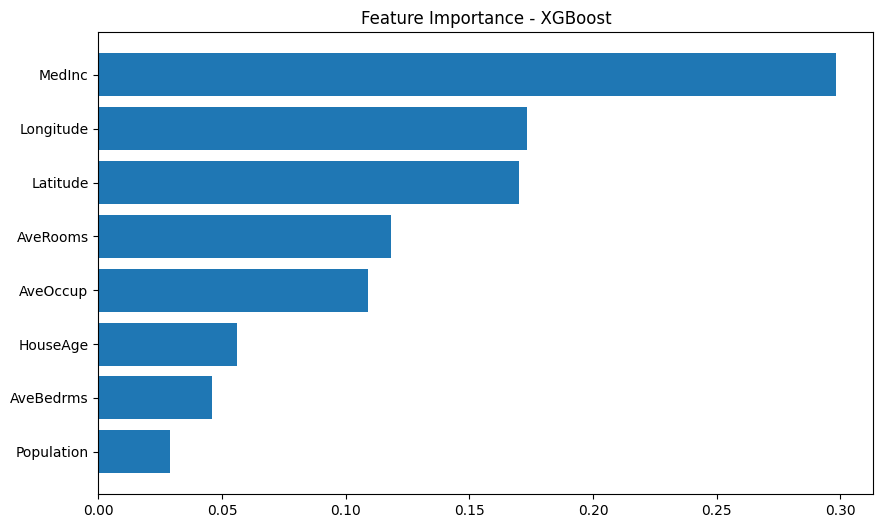

In [23]:
# Features importance

import pandas as pd
import matplotlib.pyplot as plt

# Obtener importancia
importances = best_xgb.feature_importances_

feature_names = X_train.columns

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(fi_df['feature'], fi_df['importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance - XGBoost")
plt.show()


In [24]:
#SHAP


import shap

# Crear explainer
explainer = shap.Explainer(best_xgb, X_train)

# Calcular valores SHAP
shap_values = explainer(X_test)

100%|===================| 4109/4128 [02:51<00:00]       

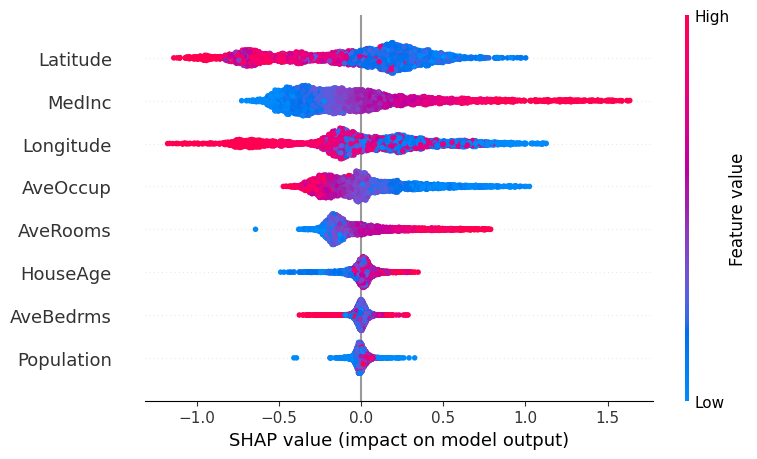

In [25]:
shap.summary_plot(shap_values, X_test)

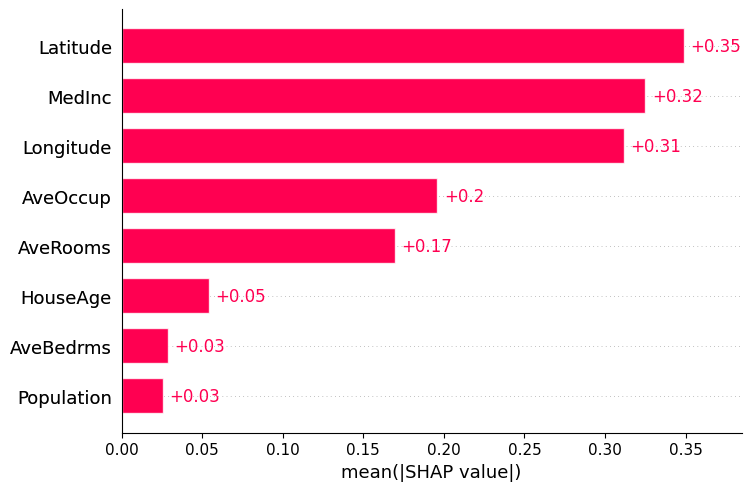

In [26]:
shap.plots.bar(shap_values)

In [ ]:
## Conclusión: Tenemos un modelo que predice el valor medio por bloque/manzana (MedHouseVal) a partir de las otras variables.
## Como variables importantes que impactan en general al valor medio de las casas de la manzana, tenemos El ingreso medio de los habitantes(miesntras más alto, más valen, la relación no es la misma hacia abajo, es decir, si son bajos , el valor baja hasta cierto punto), la ubicación geografica LAT-LONG, Ocupación promedio (Hacinamiento, impacta negativamente), cantidad de ambientes impacta positibvamente.